# Evaluate

This notebook evaluates the quality of the online alignments in a given experiment directory.

In [ ]:
%matplotlib inline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import os.path
from pathlib import Path
import pandas as pd
import pickle
import re
import import_ipynb
import system_utils
import eval_tools

## Calculate Alignment Errors

First we calculate the alignment errors of a given system on all evaluated measures.

In [2]:
systems = ['DTW', 'NOA', 'NOA_MONO', 'OLTW', 'OLTW_GLOBAL_E', 'NOA_NN']
lags = [0, 100, 200, 300, 400, 500]
scenarios_dir = 'scenarios'

### Evaluate Alignment

In [25]:
evaluating_match = False
EXP_DIR = f"experiments{'_match' if evaluating_match else ''}"
EVAL_DIR = f"eval{'_match' if evaluating_match else ''}"
for system_idx in range(len(systems)):
    exp_dir = f'{EXP_DIR}/{systems[system_idx]}'
    eval_dir = f'{EVAL_DIR}/{exp_dir[18:] if evaluating_match else exp_dir[12:]}'
    eval_tools.eval_alignment_batch(exp_dir, scenarios_dir, eval_dir)

Evaluation complete. Success: 45, Failed: 0. Results saved to eval/DTW/errs.pkl
Evaluation complete. Success: 45, Failed: 0. Results saved to eval/NOA/errs.pkl
Evaluation complete. Success: 45, Failed: 0. Results saved to eval/NOA_MONO/errs.pkl
Evaluation complete. Success: 45, Failed: 0. Results saved to eval/OLTW/errs.pkl
Evaluation complete. Success: 45, Failed: 0. Results saved to eval/OLTW_GLOBAL_E/errs.pkl
experiments/NOA_NN/s12/hyp.npy does not exist
experiments/NOA_NN/s13/hyp.npy does not exist
experiments/NOA_NN/s14/hyp.npy does not exist
experiments/NOA_NN/s16/hyp.npy does not exist
experiments/NOA_NN/s18/hyp.npy does not exist
experiments/NOA_NN/s19/hyp.npy does not exist
experiments/NOA_NN/s24/hyp.npy does not exist
experiments/NOA_NN/s26/hyp.npy does not exist
experiments/NOA_NN/s28/hyp.npy does not exist
experiments/NOA_NN/s29/hyp.npy does not exist
experiments/NOA_NN/s30/hyp.npy does not exist
experiments/NOA_NN/s31/hyp.npy does not exist
experiments/NOA_NN/s32/hyp.npy d

## Plot Error vs Tolerance

We can visualize the results by plotting the error rate across a range of error tolerances.

In [3]:
def plotErrorVsTolerance(eval_dirs, maxTol, savefile = None, style='bar', tols = None, bar_tols=None):
    '''
    Plots the error rate across a range of error tolerances.
    
    Inputs
    eval_dir: the eval directories to plot
    maxTol: maximum error tolerance to consider (in milliseconds)
    savefile: if specified, will save the figure to the given filepath
    style: 'bar' or 'line'
    tols: list of error tolerances to evaluate at
    bar_tols: list of error tolerances to plot if using 'bar'
    '''
    
    errRates_list = []
    #color=['blue','orange','green','lightgreen','red'] # hard coded for main results figure
    for i, eval_dir in enumerate(eval_dirs):
    
        # load
        with open(f'{eval_dir}/errs.pkl', 'rb') as f:
            d = pickle.load(f)

        # flattened list
        errs = []
        for scenario_id in d:
            errs = np.append(errs, d[scenario_id])

        # calculate error rates
        if tols is None:
            tols = np.arange(maxTol+1)
        if bar_tols is None:
            bar_tols = tols
        errRates = np.zeros(len(tols))
        for j in range(len(tols)):
            errRates[j] = np.mean(np.abs(errs) > tols[j]/1000)
        errRates_list.append(errRates)
        
        if style == 'line':
            plt.plot(tols, errRates * 100.0)
        elif style == 'bar':
            bar_width = 0.1
            errs = [errRates[tol] * 100.0 for tol in range(len(bar_tols))]
            pos = np.arange(len(errs)) + i * bar_width
            # hard code for main results figure
            #plt.bar(pos, errs, width=bar_width, label=os.path.basename(eval_dir), color = color[i])
            plt.bar(pos, errs, width=bar_width, label=os.path.basename(eval_dir))
            plt.xticks([r + bar_width*len(eval_dirs)/2 for r in range(len(bar_tols))], map(str, bar_tols))
        
    plt.ylabel('Error Rate (%)')
    plt.xlabel('Error Tolerance (ms)')
    plt.legend([os.path.basename(eval_dir) for eval_dir in eval_dirs])
    plt.grid(linestyle='--')
    plt.title('Error Rate vs Error Tolerance')
    plt.show()
    if savefile:
        plt.savefig(savefile)

    return errRates_list, tols

Plot the error rate vs error tolerance curve for one system of interest:

eval/NOA_MONO


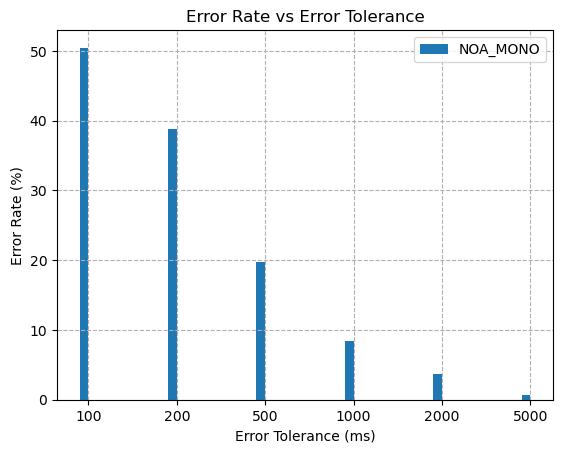

In [4]:
maxTol = 5000 # in milliseconds
tols = [100,200,500, 1000, 2000, 5000]
eval_dir = f'eval/{systems[2]}'
print(eval_dir)
errRates_list, tols = plotErrorVsTolerance([eval_dir], maxTol, tols = tols, savefile=False)

Overlay multiple error curves for comparison:

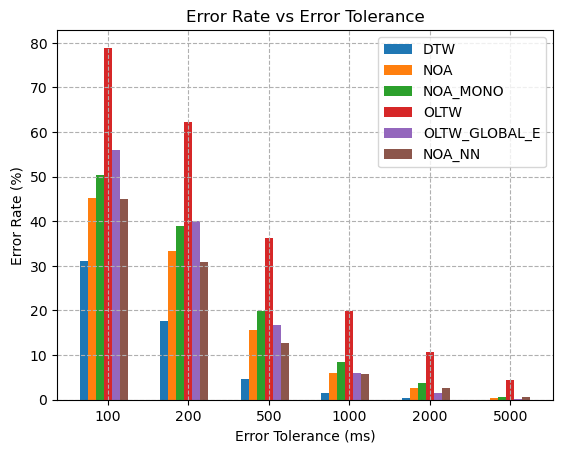

In [5]:
systems_to_compare = systems
eval_dirs = [f'eval/{s}' for s in systems_to_compare]
errRates_list, tols = plotErrorVsTolerance(eval_dirs, maxTol = 1000,tols = tols)